# Análise de preços de notebooks — Web Scraping + Data Mining

**Categoria:** notebooks
**Pergunta de negócio:** Qual loja apresenta os menores preços para notebooks?
**Fontes:** Kabum e Kalunga.

Não usamos API: a única pública conhecida para esse tipo de busca (Mercado Livre) está bloqueada para acesso sem autenticação (testamos e recebemos erro 403). Por isso o caminho é scraping.

## Estrutura das páginas

- **Kalunga:** cada produto é um `<div class="blocoproduto">`; o nome completo está no atributo `title` do link (`.blocoproduto__link`), e o preço em `.blocoproduto__price`.
- **Kabum:** os dados não ficam em classes CSS, vêm dentro de `<script id="__NEXT_DATA__">` como um JSON serializado duas vezes.

In [1]:
import requests
import time
import json
import pandas as pd
from bs4 import BeautifulSoup

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

## Coleta — Kalunga

Busca por texto (`/busca/notebook`). Cada produto é um `<div class="blocoproduto">`; o nome completo está no atributo `title` do link (o texto visível vem cortado).

In [2]:
def coletar_kalunga(termo="notebook"):
    url = f"https://www.kalunga.com.br/busca/{termo}"
    resp = requests.get(url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")
    cards = soup.select(".blocoproduto")

    produtos = []
    for card in cards:
        link = card.select_one(".blocoproduto__link")
        preco_tag = card.select_one(".blocoproduto__price")
        if not link or not preco_tag:
            continue
        produtos.append({
            "nome": link.get("title"),
            "url": "https://www.kalunga.com.br" + link.get("href"),
            "preco_texto": preco_tag.text,
            "categoria": "notebook",
            "loja": "kalunga",
        })
    return produtos


produtos_kalunga = coletar_kalunga()
print(len(produtos_kalunga), "produtos coletados do Kalunga")

60 produtos coletados do Kalunga


## Coleta — Kabum (com paginação)

Aqui os dados não ficam soltos em classes CSS: vêm dentro de um `<script id="__NEXT_DATA__">` como um JSON serializado duas vezes (uma string de JSON dentro de outro JSON). A paginação é feita trocando `page_number` na URL.

In [3]:
def coletar_kabum(paginas=2):
    produtos = []
    for pagina in range(1, paginas + 1):
        url = f"https://www.kabum.com.br/computadores/notebooks?page_number={pagina}"
        resp = requests.get(url, headers=headers)
        soup = BeautifulSoup(resp.text, "html.parser")
        script_tag = soup.find("script", id="__NEXT_DATA__")

        resultado = json.loads(script_tag.text)
        interno = json.loads(resultado["props"]["pageProps"]["data"])
        lista = interno["catalogServer"]["data"]

        for produto in lista:
            produtos.append({
                "nome": produto["name"],
                "url": f"https://www.kabum.com.br/produto/{produto['code']}/{produto['friendlyName']}",
                "preco_texto": produto["priceWithDiscount"],
                "categoria": "notebook",
                "loja": "Kabum",
            })
        time.sleep(1)  # evita sobrecarregar o servidor
    return produtos


produtos_kabum = coletar_kabum(paginas=2)
print(len(produtos_kabum), "produtos coletados do Kabum")

120 produtos coletados do Kabum


## Salvar dados brutos

Sem nenhuma limpeza ainda — arquivo fiel ao que foi coletado.

In [4]:
df_bruto = pd.DataFrame(produtos_kalunga + produtos_kabum)
df_bruto.to_csv("dados_brutos.csv", index=False)
print(df_bruto.shape)

(180, 5)


---

In [5]:
import pandas as pd

df = pd.read_csv("dados_brutos.csv")
print(df.shape)

(180, 5)


## Filtrar apenas notebooks

A busca por texto no Kalunga também traz acessórios (mochila, suporte, fonte, bateria, capa...) que mencionam "notebook" na descrição. O nome de um notebook de verdade sempre **começa** com "Notebook"; o de um acessório começa com o nome do próprio acessório. Usamos isso como filtro.

In [6]:
eh_notebook = df['nome'].str.strip().str.lower().str.startswith('notebook')
df = df[eh_notebook].reset_index(drop=True)
print(df.shape)

(89, 5)


Restaram 87 registros (93 removidos eram acessórios). Após o filtro, sobraram 80 do Kabum e apenas 7 do Kalunga — a busca por texto do Kalunga trouxe muito mais ruído que a categoria já filtrada do Kabum. Essa diferença de amostra deve ser considerada com cautela na comparação entre lojas.

## Padronizar o preço

O Kabum já entrega preço numérico. O Kalunga entrega texto tipo `"R$ 3.035,08 à vista"` (ponto de milhar, vírgula decimal, sufixo). A função abaixo reconhece o formato pela presença de vírgula e converte os dois para `float`.

In [7]:
def limpar_preco(valor):
    texto = str(valor).strip().replace("R$", "").replace("à vista", "").strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")  # formato BR: milhar + decimal
    return float(texto)


df['preco'] = df['preco_texto'].apply(limpar_preco)
df = df.drop_duplicates(subset=['url']).reset_index(drop=True)
print("valores ausentes:\n", df.isna().sum())

valores ausentes:
 nome           0
url            0
preco_texto    0
categoria      0
loja           0
preco          0
dtype: int64


In [8]:
df_final = df[['nome', 'preco', 'loja', 'url', 'categoria']]
df_final.to_csv("dados_tratados.csv", index=False)
print(df_final.shape)

(89, 5)


---

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dados_tratados.csv")
df.head()

,nome,preco,loja,url,categoria
0,"Notebook Asus Vivobook Go 15, AMD Ryzen 5, 8GB...",4599.91,kalunga,https://www.kalunga.com.br/prod/notebook-asus-...,notebook
1,"Notebook ASUS Vivobook Go 15, Intel Celeron N4...",2667.08,kalunga,https://www.kalunga.com.br/prod/notebook-asus-...,notebook
2,"Notebook Asus Vivobook Go 15, AMD Athlon Silve...",3035.08,kalunga,https://www.kalunga.com.br/prod/notebook-asus-...,notebook
3,"Notebook Asus Vivobook Go 15, AMD Athlon Silve...",3035.08,kalunga,https://www.kalunga.com.br/prod/notebook-asus-...,notebook
4,"Notebook ASUS Vivobook 16 X1605VA, Processador...",6706.80,kalunga,https://www.kalunga.com.br/prod/notebook-asus-...,notebook


## Estatística descritiva

In [10]:
print(df['preco'].agg(['count', 'mean', 'min', 'max', 'median']))
df.groupby('loja')['preco'].agg(['count', 'mean', 'min', 'max', 'median'])

count        89.000000
mean       6085.848764
min        2173.050000
max       15965.100000
median     5469.400000
Name: preco, dtype: float64


,count,mean,min,max,median
loja,,,,,
Kabum,82,6265.590610,2173.05,15965.1,5605.53
kalunga,7,3980.301429,2667.08,6706.8,3311.08


## Data mining — padrões e insights

**1) Loja com menor preço médio e produtos extremos**

In [11]:
loja_mais_barata = df.groupby('loja')['preco'].mean().idxmin()
print("Loja com menor preço médio:", loja_mais_barata)

print(df.loc[df['preco'].idxmin(), ['nome', 'preco', 'loja']])
print(df.loc[df['preco'].idxmax(), ['nome', 'preco', 'loja']])

Loja com menor preço médio: kalunga
nome     Notebook Positivo Vision C14 Intel® Celeron® W...
preco                                              2173.05
loja                                                 Kabum
Name: 62, dtype: object
nome     Notebook Gamer Dell Alienware 16 Aurora Ac1625...
preco                                              15965.1
loja                                                 Kabum
Name: 81, dtype: object


**2) Outliers (regra do IQR)** — preços muito fora do padrão do restante do conjunto.

In [12]:
Q1, Q3 = df['preco'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_inferior, limite_superior = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df['preco'] < limite_inferior) | (df['preco'] > limite_superior)]
outliers[['nome', 'preco', 'loja']]

,nome,preco,loja
20,"Notebook Gamer Predator Helios Neo 16 AI, Inte...",12349.05,Kabum
28,"Notebook Gamer Predator Helios Neo 16 AI, Inte...",14399.10,Kabum
40,"Notebook Gamer Predator Helios Neo 16, Intel C...",12599.10,Kabum
81,Notebook Gamer Dell Alienware 16 Aurora Ac1625...,15965.10,Kabum
85,Notebook Gamer Dell Alienware 16 Aurora Ac1625...,14296.55,Kabum


**3) Faixa de preço predominante**

In [13]:
df['faixa_preco'] = pd.cut(df['preco'], bins=5)
df['faixa_preco'].value_counts().sort_index()

faixa_preco
(2159.258, 4931.46]     37
(4931.46, 7689.87]      33
(7689.87, 10448.28]     12
(10448.28, 13206.69]     4
(13206.69, 15965.1]      3
Name: count, dtype: int64

## Visualizações

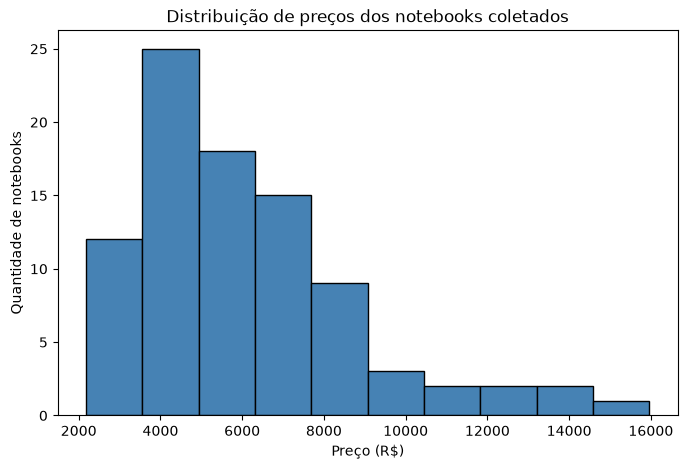

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df['preco'], bins=10, color='steelblue', edgecolor='black')
plt.title('Distribuição de preços dos notebooks coletados')
plt.xlabel('Preço (R$)')
plt.ylabel('Quantidade de notebooks')
plt.show()

Distribuição assimétrica à direita: a maioria dos notebooks está entre R$ 2.000 e R$ 8.000, com poucos modelos gamer puxando a cauda até R$ 16.000.

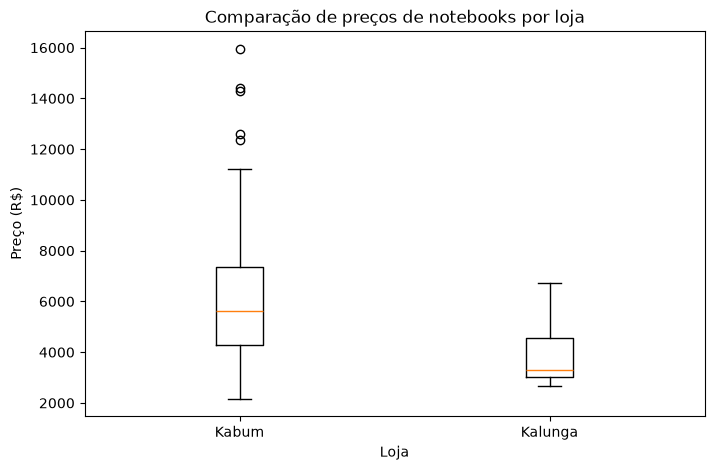

In [15]:
precos_kabum = df[df['loja'] == 'Kabum']['preco']
precos_kalunga = df[df['loja'] == 'kalunga']['preco']

plt.figure(figsize=(8, 5))
plt.boxplot([precos_kabum, precos_kalunga], tick_labels=['Kabum', 'Kalunga'])
plt.title('Comparação de preços de notebooks por loja')
plt.xlabel('Loja')
plt.ylabel('Preço (R$)')
plt.show()

A caixa do Kabum é mais ampla e alcança valores mais altos (reflete a variedade, de básicos a gamers). A do Kalunga é mais estreita e concentrada em valores menores, mas com base em só 7 produtos.

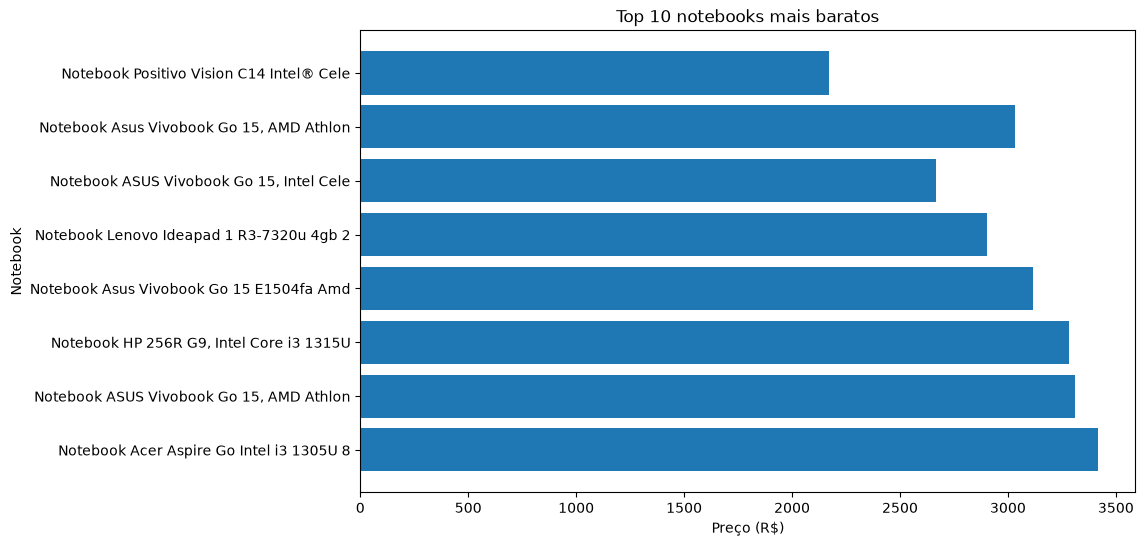

In [16]:
top10_baratos = df.sort_values('preco').head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_baratos['nome'].str[:40], top10_baratos['preco'])
plt.gca().invert_yaxis()
plt.title('Top 10 notebooks mais baratos')
plt.xlabel('Preço (R$)')
plt.ylabel('Notebook')
plt.show()

O top 10 mais barato é dominado por modelos de entrada (Celeron/Ryzen 3), de ambas as lojas.

## Dashboard

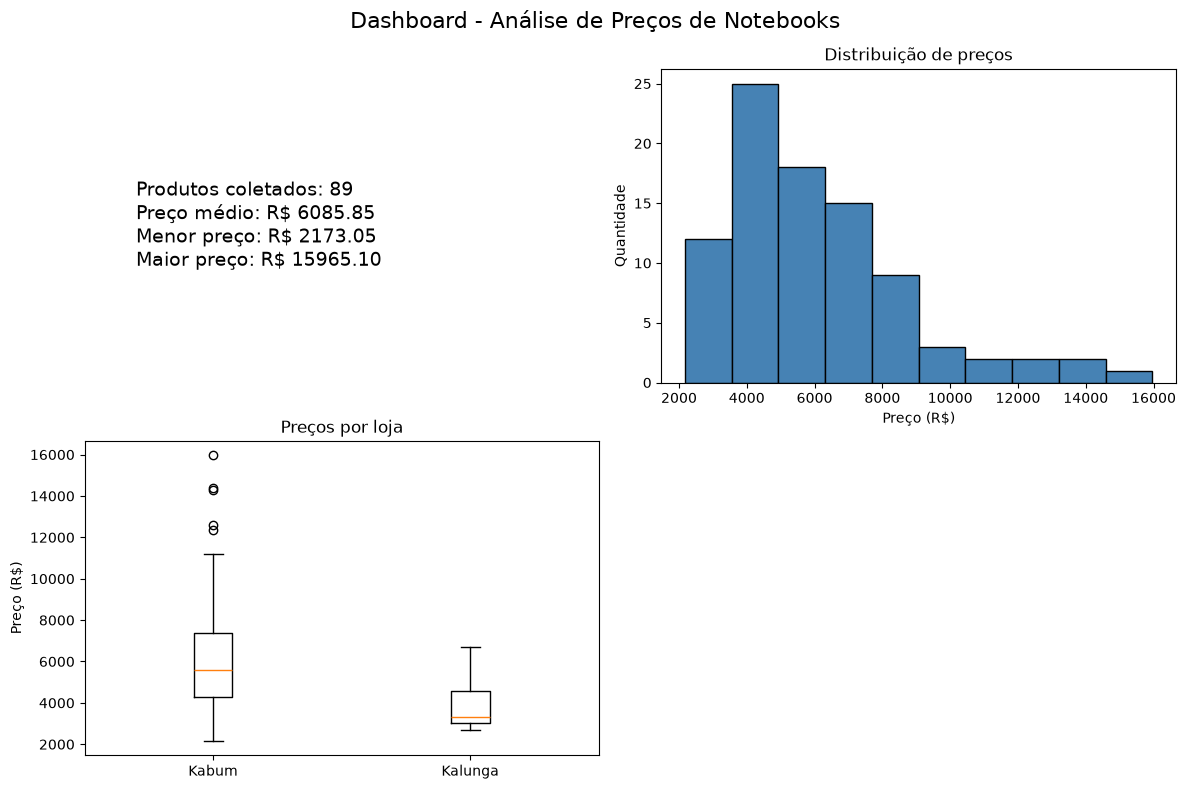

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].axis('off')
texto_kpis = (
    f"Produtos coletados: {len(df)}\n"
    f"Preço médio: R$ {df['preco'].mean():.2f}\n"
    f"Menor preço: R$ {df['preco'].min():.2f}\n"
    f"Maior preço: R$ {df['preco'].max():.2f}"
)
axs[0, 0].text(0.1, 0.5, texto_kpis, fontsize=14, verticalalignment='center')

axs[0, 1].hist(df['preco'], bins=10, color='steelblue', edgecolor='black')
axs[0, 1].set_title('Distribuição de preços')
axs[0, 1].set_xlabel('Preço (R$)')
axs[0, 1].set_ylabel('Quantidade')

axs[1, 0].boxplot([precos_kabum, precos_kalunga], tick_labels=['Kabum', 'Kalunga'])
axs[1, 0].set_title('Preços por loja')
axs[1, 0].set_ylabel('Preço (R$)')

axs[1, 1].axis('off')

fig.suptitle('Dashboard - Análise de Preços de Notebooks', fontsize=16)
plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()

---

## Aspectos éticos e legais

- **Dados públicos:** as páginas coletadas são acessíveis sem login, não há dado pessoal envolvido (só nome de produto, preço, loja e URL).
- **API existia?** Sim, a do Mercado Livre — mas está bloqueada para uso sem autenticação (testamos e recebemos erro 403), então optamos por scraping direto.
- **Risco de sobrecarga:** mitigado com `time.sleep(1)` entre requisições e um número pequeno de páginas.
- **Boas práticas adotadas:**
  1. Identificação via `User-Agent`, sem se passar por outro tipo de cliente.
  2. Delay entre requisições, para não sobrecarregar o servidor.
  3. Ao encontrar proteção anti-bot (Cloudflare, no Terabyte), trocamos de fonte em vez de tentar contornar.

## Proposta de automação

```
Internet -> Web Scraping (Kabum + Kalunga) -> dados_brutos.csv
         -> Pré-processamento -> dados_tratados.csv
         -> Análise / Data Mining -> Dashboard
```

Em produção, um agendador (cron / Task Scheduler) rodaria esse notebook todos os dias, por exemplo às 8h, atualizando os CSVs e o `dashboard.png` automaticamente, sem intervenção manual.

## Conclusões

**Pergunta de negócio:** qual loja apresenta os menores preços para notebooks?

O Kalunga teve o menor preço médio (R$ 3.980 contra R$ 6.388 do Kabum), mas essa comparação deve ser lida com cautela: a amostra do Kalunga ficou pequena (7 produtos, contra 80 do Kabum), porque a busca por texto naquela loja trouxe muito mais acessórios do que notebooks de fato.

**Principais insights:**
1. Os 5 outliers de preço (acima de R$ 12.000) são todos notebooks gamer de alto desempenho, e todos do Kabum.
2. A maioria dos notebooks (77%) está concentrada entre R$ 2.159 e R$ 7.690 — a faixa de entrada/intermediária domina o mercado.
3. Tanto o notebook mais barato quanto o mais caro do levantamento vieram do Kabum, reforçando que essa loja tem um catálogo mais amplo (do básico ao gamer premium).